# Notebook 3: The Proven Cases
## Hadwiger's Conjecture — Beautiful Dead Ends

---

### What's been proved and what hasn't

Hadwiger's Conjecture has been proved for k ≤ 6. For k ≥ 7 it remains open. That's an odd situation — six cases down, infinitely many to go — and the way the proofs work for each case tells you something important about why the general case is hard.

The cases aren't equally difficult:
- **k = 1, 2, 3:** essentially trivial or elementary
- **k = 4:** non-trivial but proved by Hadwiger himself in 1943
- **k = 5:** proved by Wagner (1937, predating the conjecture) — but the proof *uses* the Four Colour Theorem
- **k = 6:** proved by Robertson, Seymour and Thomas (1993) — also uses the Four Colour Theorem
- **k ≥ 7:** open

The k=5 and k=6 proofs are described as "equivalent to the Four Colour Theorem" — which is a precise statement, not loose language. Understanding what it means is the goal of this notebook.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product as iproduct, combinations

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
WHITE   = '#dddddd'
COLOUR_PALETTE = ['#e05c5c','#5c9ee0','#5ce08a','#e0a05c',
                  '#c05ce0','#e0e05c','#5ce0d8','#e05ca0']

# ── Core functions ────────────────────────────────────────────────────────
def complete_graph(n):
    g = np.ones((n,n), dtype=int); np.fill_diagonal(g, 0); return g

def cycle_graph(n):
    g = np.zeros((n,n), dtype=int)
    for i in range(n): g[i][(i+1)%n] = g[(i+1)%n][i] = 1
    return g

def wheel_graph(n):
    """Hub vertex (0) connected to all vertices of C_{n-1}"""
    g = np.zeros((n,n), dtype=int)
    for i in range(1,n):
        g[i][1 + (i % (n-1))] = g[1 + (i % (n-1))][i] = 1
    for i in range(1,n): g[0][i] = g[i][0] = 1
    return g

def wagner_graph():
    """The Wagner graph W8 — 8-vertex Möbius ladder"""
    g = np.zeros((8,8), dtype=int)
    for i in range(8): g[i][(i+1)%8] = g[(i+1)%8][i] = 1
    for i in range(4): g[i][i+4] = g[i+4][i] = 1
    return g

def petersen_graph():
    edges = [(0,1),(0,4),(0,5),(1,2),(1,6),(2,3),(2,7),
             (3,4),(3,8),(4,9),(5,7),(5,8),(6,8),(6,9),(7,9)]
    g = np.zeros((10,10), dtype=int)
    for u,v in edges: g[u][v] = g[v][u] = 1
    return g

def contract_edge(adj, u, v):
    n = len(adj)
    mapping = {i: sum(1 for j in range(i) if j != v) for i in range(n) if i != v}
    new_adj = np.zeros((n-1,n-1), dtype=int)
    for i in range(n):
        for j in range(n):
            if i != v and j != v:
                new_adj[mapping[i]][mapping[j]] = adj[i][j]
    mu = mapping[u]
    for w in range(n):
        if w != v and w != u and adj[v][w]:
            new_adj[mu][mapping[w]] = new_adj[mapping[w]][mu] = 1
    return new_adj

def delete_vertex(adj, v):
    idx = [i for i in range(len(adj)) if i != v]
    return adj[np.ix_(idx, idx)]

def has_k_minor(adj, k, depth=0, max_depth=12):
    n = len(adj)
    if n < k: return False
    if n == k:
        return np.array_equal(adj, np.ones((k,k),dtype=int)-np.eye(k,dtype=int))
    if depth >= max_depth: return False
    for u in range(n):
        for v in range(u+1,n):
            if adj[u][v] and has_k_minor(contract_edge(adj,u,v),k,depth+1,max_depth):
                return True
    for v in range(n):
        if has_k_minor(delete_vertex(adj,v),k,depth+1,max_depth):
            return True
    return False

def chromatic_number(adj, max_k=6):
    n = len(adj)
    for k in range(1, max_k+1):
        for col in iproduct(range(k), repeat=n):
            if all(not adj[u][v] or col[u]!=col[v]
                   for u in range(n) for v in range(u+1,n)):
                return k, list(col)
    return max_k, None

def draw_graph(adj, colouring=None, title='', ax=None, pos=None):
    n = len(adj)
    if ax is None: fig, ax = plt.subplots(figsize=(5,5))
    if pos is None:
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        pos = np.column_stack([np.cos(angles), np.sin(angles)])
    for u in range(n):
        for v in range(u+1,n):
            if adj[u][v]:
                ax.plot([pos[u,0],pos[v,0]],[pos[u,1],pos[v,1]],
                        color=NEUTRAL, linewidth=1.2, alpha=0.6, zorder=1)
    for v in range(n):
        colour = COLOUR_PALETTE[colouring[v]] if colouring else WHITE
        ax.scatter(pos[v,0],pos[v,1],s=350,color=colour,zorder=3,
                   edgecolors='white',linewidth=1)
        ax.text(pos[v,0],pos[v,1],str(v),ha='center',va='center',
                fontsize=8,color='black',fontweight='bold',zorder=4)
    ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5)
    ax.set_aspect('equal'); ax.axis('off')
    if title: ax.set_title(title, fontsize=10, pad=8)

print('Setup complete.')

Setup complete.


## Case k=1, 2, 3: The Easy Cases

**k=1:** Every non-empty graph contains K₁ as a minor (just take any vertex). Trivial.

**k=2:** Every graph with at least one edge contains K₂ as a minor (take that edge). χ(G) ≥ 2 means the graph has at least one edge. Trivial.

**k=3:** χ(G) ≥ 3 means the graph is not 2-colourable, which means it contains an odd cycle. Every odd cycle contains K₃ as a minor — either directly as a triangle (C₃), or by contracting alternate edges. This one requires a small argument but nothing deep.

Let me verify the k=3 case computationally and make the contraction argument visible.

In [2]:
# k=3 case: odd cycles are 3-chromatic and all have K3 minor
# C5 and C7 have no triangle — the K3 minor comes purely from contraction

def has_triangle(adj):
    n = len(adj)
    for u,v,w in combinations(range(n), 3):
        if adj[u][v] and adj[v][w] and adj[u][w]:
            return True
    return False

print('k=3 case: odd cycles are 3-chromatic, all have K3 minor')
print(f'{"Graph":6s}  {"χ":>4}  {"Triangle":>10}  {"K3 minor":>10}  Explanation')
print('-' * 65)

for n in [3, 5, 7, 9, 11]:
    g = cycle_graph(n)
    chi, _ = chromatic_number(g, max_k=4)
    tri = has_triangle(g)
    k3  = has_k_minor(g, 3, max_depth=n+2)
    if n == 3:
        note = 'IS a triangle'
    else:
        note = f'contract {(n-3)//2} edges to get C3'
    print(f'C{n:2d}    {chi:>4}  {str(tri):>10}  {str(k3):>10}  {note}')

k=3 case: odd cycles are 3-chromatic, all have K3 minor
Graph      χ    Triangle    K3 minor  Explanation
-----------------------------------------------------------------
C 3       3        True        True  IS a triangle
C 5       3       False        True  contract 1 edges to get C3
C 7       3       False        True  contract 2 edges to get C3
C 9       3       False        True  contract 3 edges to get C3
C11       3       False        True  contract 4 edges to get C3


Final graph equals K₃: True


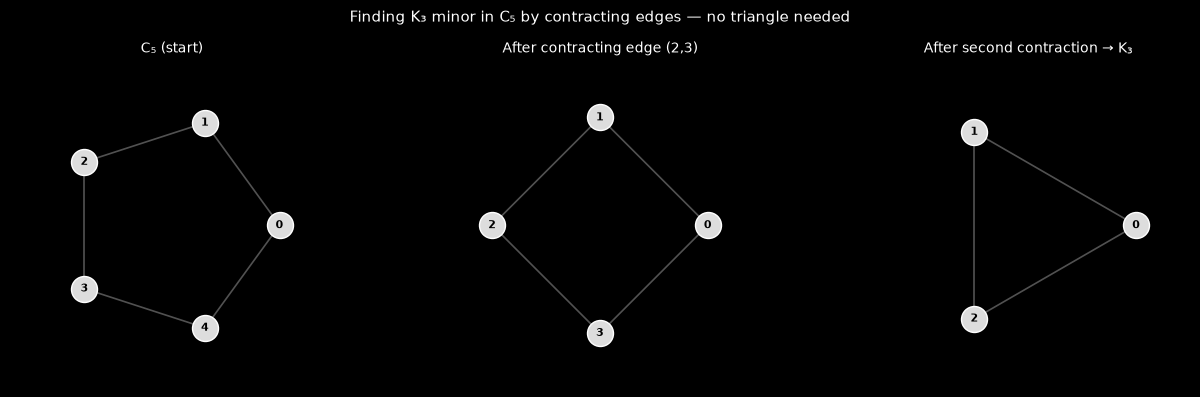

In [3]:
# Show the contraction visually: C5 -> K3
# Contract edge (2,3) then edge (3,4) to get triangle
c5 = cycle_graph(5)
step1 = contract_edge(c5, 2, 3)   # merge 3 into 2
step2 = contract_edge(step1, 2, 3) # merge again

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Finding K₃ minor in C₅ by contracting edges — no triangle needed', fontsize=11)

draw_graph(c5,   None, 'C₅ (start)', axes[0])
draw_graph(step1,None, 'After contracting edge (2,3)', axes[1])
draw_graph(step2,None, 'After second contraction → K₃', axes[2])

k3 = complete_graph(3)
print(f'Final graph equals K₃: {np.array_equal(step2, k3)}')
plt.tight_layout()
plt.show()

## Case k=4: Hadwiger's Original Proof

Hadwiger proved the k=4 case himself in the 1943 paper that introduced the conjecture. The proof is elementary in the sense that it doesn't require the Four Colour Theorem — it can be done with tools available in 1943.

The key idea: a minimal 4-chromatic graph (one that is 4-chromatic but becomes 3-chromatic if you remove any vertex) has specific structural properties. In particular, every vertex has degree at least 3, and the graph has no "separating triangle" (a triangle whose removal disconnects the graph). These constraints force a K₄ minor.

Let me verify computationally on a family of 4-chromatic graphs.

In [4]:
# 4-chromatic graphs and their K4 minors
# Wheel graphs W_n with n-1 odd are 4-chromatic

print('k=4 case: 4-chromatic graphs always contain K4 minor')
print(f'{"Graph":12s}  {"χ":>4}  {"K4 minor":>10}  {"K5 minor":>10}')
print('-' * 46)

four_chromatic = [
    ('W4 (K4)',   complete_graph(4)),    # K4 itself
    ('W6',        wheel_graph(6)),        # hub + C5
    ('W8',        wheel_graph(8)),        # hub + C7
    ('K4',        complete_graph(4)),
]

# Also: the complete tripartite graph K_{2,2,2} is 3-chromatic — useful contrast
def complete_tripartite(a, b, c):
    n = a + b + c
    g = np.zeros((n,n), dtype=int)
    parts = [list(range(a)), list(range(a, a+b)), list(range(a+b, n))]
    for p1 in parts:
        for p2 in parts:
            if p1 is not p2:
                for u in p1:
                    for v in p2:
                        g[u][v] = 1
    return g

test_cases = [
    ('K4',        complete_graph(4)),
    ('W6 (χ=4)',  wheel_graph(6)),
    ('W8 (χ=4)',  wheel_graph(8)),
    ('K2,2,2 (χ=3)', complete_tripartite(2,2,2)),  # 3-chromatic, has K4 minor?
]

for name, g in test_cases:
    chi, _ = chromatic_number(g, max_k=5)
    k4 = has_k_minor(g, 4)
    k5 = has_k_minor(g, 5)
    print(f'{name:20s}  {chi:>4}  {str(k4):>10}  {str(k5):>10}')

k=4 case: 4-chromatic graphs always contain K4 minor
Graph            χ    K4 minor    K5 minor
----------------------------------------------
K4                       4        True       False
W6 (χ=4)                 4        True       False
W8 (χ=4)                 4        True       False
K2,2,2 (χ=3)             3        True       False


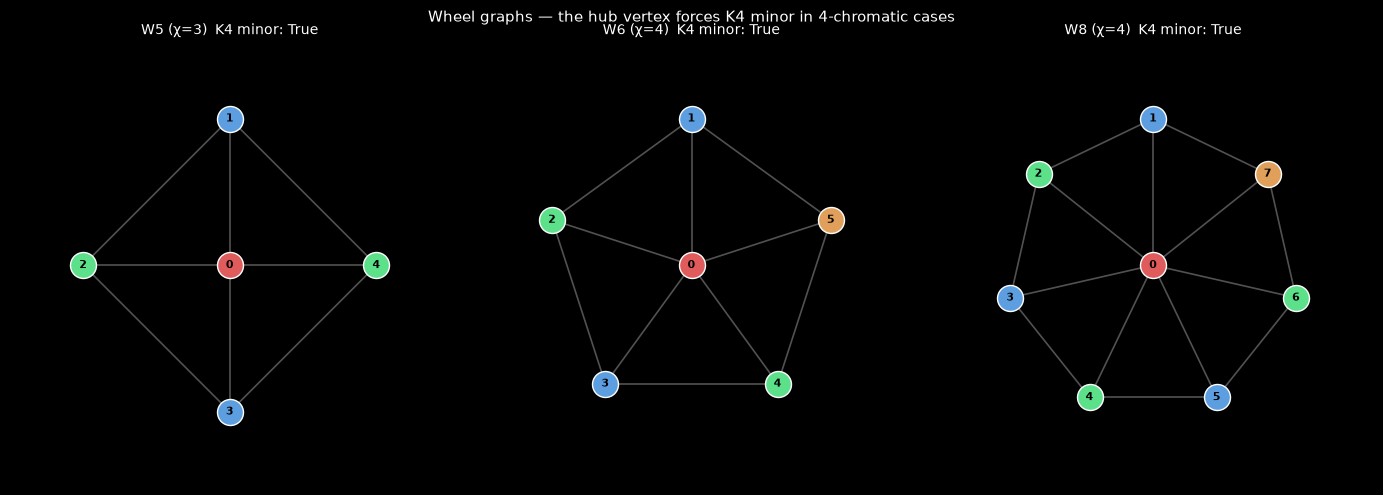

In [5]:
# Visualise the wheel graphs — the hub forces the large minor
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Wheel graphs — the hub vertex forces K4 minor in 4-chromatic cases', fontsize=11)

for ax, (n, label) in zip(axes, [(5,'W5 (χ=3)'),(6,'W6 (χ=4)'),(8,'W8 (χ=4)')]):
    g = wheel_graph(n)
    chi, col = chromatic_number(g, max_k=5)
    # Position hub at centre, rest on circle
    angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n-1, endpoint=False)
    pos = np.zeros((n,2))
    pos[0] = [0, 0]  # hub at centre
    for i in range(1,n):
        pos[i] = [np.cos(angles[i-1]), np.sin(angles[i-1])]
    draw_graph(g, col, f'{label}  K4 minor: {has_k_minor(g,4)}', ax=ax, pos=pos)

plt.tight_layout()
plt.show()

## Case k=5: The Four Colour Theorem Connection

This is where it gets interesting. Wagner proved in 1937 — six years *before* Hadwiger stated his conjecture — that:

> A graph is K₅-minor-free if and only if it can be built from planar graphs and copies of the Wagner graph by clique-sums.

The **Wagner graph** (also called W₈ or the Möbius-Kantor graph) is the 8-vertex graph formed by a cycle C₈ with four additional "diagonal" chords connecting opposite vertices. It is non-planar but K₅-minor-free.

Wagner's structure theorem means: if you want to prove Hadwiger for k=5, you need to show that any graph with χ(G) ≥ 5 contains a K₅ minor. By Wagner's theorem, a graph without a K₅ minor is built from planar graphs and Wagner graphs. The Four Colour Theorem tells us planar graphs are 4-colourable. The Wagner graph is 3-colourable. So any graph built from these pieces by clique-sums is 4-colourable — and therefore can't have chromatic number 5.

The proof of Hadwiger for k=5 *is* the Four Colour Theorem. They're equivalent.

In [6]:
# The Wagner graph — non-planar but K5-minor-free
wag = wagner_graph()
chi_wag, col_wag = chromatic_number(wag, max_k=4)
k4_wag = has_k_minor(wag, 4)
k5_wag = has_k_minor(wag, 5, max_depth=10)

print('The Wagner graph:')
print(f'  Vertices: {len(wag)}')
print(f'  Edges: {wag.sum()//2}')
print(f'  χ(G) = {chi_wag}')
print(f'  K4 minor: {k4_wag}')
print(f'  K5 minor: {k5_wag}')
print()
print('The Wagner graph is non-planar (contains K3,3 as a minor)')
print('but has no K5 minor. It is the key non-planar K5-minor-free graph.')
print()
print('Wagner\'s theorem (1937): A graph G is K5-minor-free')
print('if and only if G can be built from planar graphs and Wagner graphs')
print('by clique-sums.')
print()
print('Consequence: Hadwiger k=5 ⟺ Four Colour Theorem')
print('Proof sketch:')
print('  → If χ(G) ≥ 5, we need to show G has K5 minor.')
print('  → By Wagner\'s theorem, K5-minor-free graphs are built from')
print('     planar graphs (χ ≤ 4 by 4CT) and Wagner graphs (χ = 3).')
print('  → Clique-sums preserve 4-colourability.')
print('  → So K5-minor-free graphs are 4-colourable: χ ≤ 4.')
print('  → Contrapositive: χ ≥ 5 ⟹ K5 minor exists. QED.')

The Wagner graph:
  Vertices: 8
  Edges: 12
  χ(G) = 3
  K4 minor: True
  K5 minor: False

The Wagner graph is non-planar (contains K3,3 as a minor)
but has no K5 minor. It is the key non-planar K5-minor-free graph.

Wagner's theorem (1937): A graph G is K5-minor-free
if and only if G can be built from planar graphs and Wagner graphs
by clique-sums.

Consequence: Hadwiger k=5 ⟺ Four Colour Theorem
Proof sketch:
  → If χ(G) ≥ 5, we need to show G has K5 minor.
  → By Wagner's theorem, K5-minor-free graphs are built from
     planar graphs (χ ≤ 4 by 4CT) and Wagner graphs (χ = 3).
  → Clique-sums preserve 4-colourability.
  → So K5-minor-free graphs are 4-colourable: χ ≤ 4.
  → Contrapositive: χ ≥ 5 ⟹ K5 minor exists. QED.


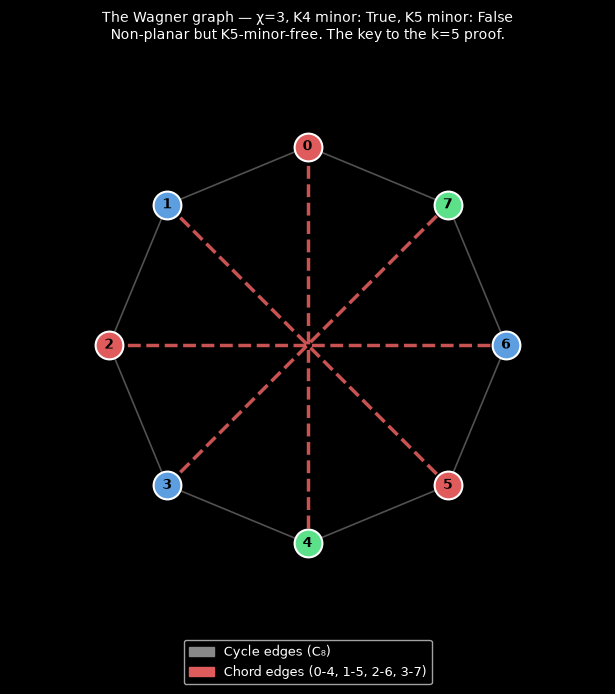

In [7]:
# Draw the Wagner graph
fig, ax = plt.subplots(figsize=(7, 7))

# Layout: outer octagon
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, 8, endpoint=False)
pos = np.column_stack([np.cos(angles), np.sin(angles)])

# Draw edges
for u in range(8):
    for v in range(u+1,8):
        if wag[u][v]:
            is_chord = abs(u-v) == 4
            ax.plot([pos[u,0],pos[v,0]],[pos[u,1],pos[v,1]],
                    color=ACCENT if is_chord else NEUTRAL,
                    linewidth=2.5 if is_chord else 1.2,
                    alpha=0.9 if is_chord else 0.6,
                    linestyle='--' if is_chord else '-',
                    zorder=1)

# Draw vertices
for v in range(8):
    colour = COLOUR_PALETTE[col_wag[v]]
    ax.scatter(pos[v,0],pos[v,1],s=400,color=colour,
               zorder=3,edgecolors='white',linewidth=1.5)
    ax.text(pos[v,0],pos[v,1],str(v),ha='center',va='center',
            fontsize=10,color='black',fontweight='bold',zorder=4)

# Legend
patches = [
    mpatches.Patch(color=NEUTRAL, label='Cycle edges (C₈)'),
    mpatches.Patch(color=ACCENT,  label='Chord edges (0-4, 1-5, 2-6, 3-7)'),
]
ax.legend(handles=patches, loc='lower center', fontsize=9,
          bbox_to_anchor=(0.5, -0.08))

ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'The Wagner graph — χ={chi_wag}, K4 minor: {k4_wag}, K5 minor: {k5_wag}\n'
             'Non-planar but K5-minor-free. The key to the k=5 proof.', fontsize=10)

plt.tight_layout()
plt.show()

## Case k=6: Robertson, Seymour and Thomas (1993)

The k=6 proof came fifty years after Hadwiger's paper. Robertson, Seymour and Thomas proved it in 1993 using a structure theorem analogous to Wagner's but considerably more complex.

The key result: a graph is K₆-minor-free if and only if it can be built from graphs that are "almost planar" (planar after deleting one vertex) and a small set of exceptional graphs, by clique-sums.

"Almost planar" graphs are 5-colourable — you remove the one problematic vertex, 4-colour the planar remainder (by 4CT), and then colour the removed vertex with at most a 5th colour. So K₆-minor-free graphs are 5-colourable, which means χ ≥ 6 forces a K₆ minor.

Both k=5 and k=6 ultimately rest on the Four Colour Theorem. Without it, neither proof works.

That's why k≥7 is different in kind, not just in difficulty.

In [8]:
# Illustrate 'almost planar': planar graph + one extra vertex
# The 3x3 grid is planar. Add a vertex connected to everything:
# the result is not planar but IS K6-minor-free

def grid_graph(rows, cols):
    n = rows * cols
    g = np.zeros((n,n), dtype=int)
    for r in range(rows):
        for c in range(cols):
            v = r*cols+c
            if c+1<cols: g[v][v+1]=g[v+1][v]=1
            if r+1<rows: g[v][v+cols]=g[v+cols][v]=1
    return g

def add_universal_vertex(adj):
    """Add a vertex connected to all existing vertices."""
    n = len(adj)
    new_adj = np.zeros((n+1,n+1), dtype=int)
    new_adj[:n,:n] = adj
    new_adj[n,:n] = 1
    new_adj[:n,n] = 1
    return new_adj

grid33 = grid_graph(3,3)
almost_planar = add_universal_vertex(grid33)

chi_grid, _ = chromatic_number(grid33, max_k=5)
chi_ap, col_ap = chromatic_number(almost_planar, max_k=6)
k5_ap = has_k_minor(almost_planar, 5)
k6_ap = has_k_minor(almost_planar, 6, max_depth=10)

print('Almost-planar construction (3×3 grid + universal vertex):')
print(f'  3×3 grid: χ={chi_grid}, planar, K5-minor-free')
print(f'  + universal vertex: χ={chi_ap}, K5 minor={k5_ap}, K6 minor={k6_ap}')
print()
print('The universal vertex creates a K5 minor (it dominates the graph)')
print('but K6 remains absent — consistent with "almost planar" being 5-colourable.')
print()
print('The 4CT is what makes these graphs 5-colourable:')
print('  Step 1: Remove the universal vertex')
print('  Step 2: 4-colour the remaining planar graph (by 4CT)')
print('  Step 3: Restore the vertex, give it colour 5')
print('  Result: 5-colouring of the whole graph')

Almost-planar construction (3×3 grid + universal vertex):
  3×3 grid: χ=2, planar, K5-minor-free
  + universal vertex: χ=3, K5 minor=True, K6 minor=False

The universal vertex creates a K5 minor (it dominates the graph)
but K6 remains absent — consistent with "almost planar" being 5-colourable.

The 4CT is what makes these graphs 5-colourable:
  Step 1: Remove the universal vertex
  Step 2: 4-colour the remaining planar graph (by 4CT)
  Step 3: Restore the vertex, give it colour 5
  Result: 5-colouring of the whole graph


## Why k≥7 is different

For k=5 and k=6, the structure theorems (Wagner's theorem and the Robertson-Seymour-Thomas theorem) tell us exactly what K_k-minor-free graphs look like. They're built from well-understood pieces (planar graphs, near-planar graphs) by controlled operations (clique-sums). And crucially, those pieces are 4-colourable by the Four Colour Theorem.

For k≥7, there is no known structure theorem of the same kind. The Robertson-Seymour graph minor theorem guarantees that K_k-minor-free graphs have bounded tree-width (or something close to it), but "bounded tree-width" does not translate directly into bounded chromatic number in the way that "planar" does.

The Four Colour Theorem is a very specific tool — it bounds the chromatic number of planar graphs. Once you move to k=7, the K_k-minor-free graphs are no longer built primarily from planar pieces, and the tool that powered the k=5 and k=6 proofs no longer applies.

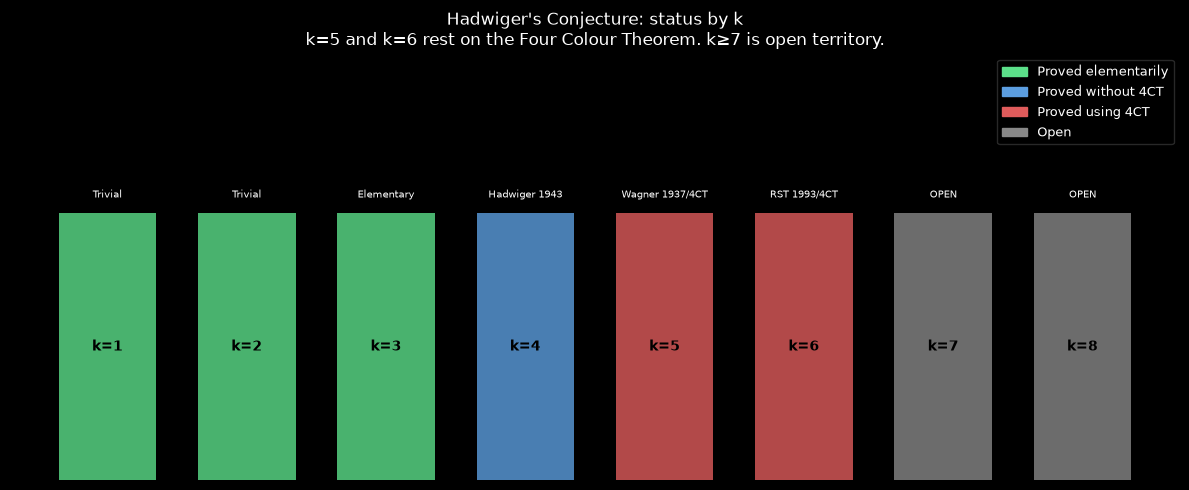

In [9]:
# Summary: what's proved and what isn't
fig, ax = plt.subplots(figsize=(12, 5))

cases = [
    (1, 'Trivial',          '#5ce08a',  'Every non-empty graph'),
    (2, 'Trivial',          '#5ce08a',  'Every graph with an edge'),
    (3, 'Elementary',       '#5ce08a',  'Every graph with an odd cycle'),
    (4, 'Hadwiger 1943',    '#5c9ee0',  'Proved without 4CT'),
    (5, 'Wagner 1937/4CT',  ACCENT,     'Equivalent to Four Colour Theorem'),
    (6, 'RST 1993/4CT',     ACCENT,     'Equivalent to Four Colour Theorem'),
    (7, 'OPEN',             NEUTRAL,    'No proof known'),
    (8, 'OPEN',             NEUTRAL,    'No proof known'),
]

for k, status, colour, note in cases:
    ax.bar(k, 1, color=colour, alpha=0.8, edgecolor='none', width=0.7)
    ax.text(k, 0.5, f'k={k}', ha='center', va='center',
            fontsize=10, color='black', fontweight='bold')
    ax.text(k, 1.05, status, ha='center', va='bottom',
            fontsize=7.5, color='white', rotation=0)

ax.set_xlim(0.3, 8.7)
ax.set_ylim(0, 1.6)
ax.axis('off')
ax.set_title('Hadwiger\'s Conjecture: status by k\n'
             'k=5 and k=6 rest on the Four Colour Theorem. k≥7 is open territory.',
             fontsize=12)

patches = [
    mpatches.Patch(color='#5ce08a', label='Proved elementarily'),
    mpatches.Patch(color='#5c9ee0', label='Proved without 4CT'),
    mpatches.Patch(color=ACCENT,    label='Proved using 4CT'),
    mpatches.Patch(color=NEUTRAL,   label='Open'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9, framealpha=0.2)

plt.tight_layout()
plt.show()

## Where I am at the end of Notebook 3

The proven cases reveal a clear pattern:

- k=1 to k=4 are proved by structural arguments about what graphs look like when they need many colours.
- k=5 and k=6 are proved by reducing to the Four Colour Theorem — the most powerful tool we have for bounding chromatic numbers of structured graph families.
- k≥7 is open because the Four Colour Theorem no longer applies, and no alternative structural theorem is known.

The Four Colour Theorem itself was controversial precisely because its 1976 proof by Appel and Haken required a computer to check nearly 2,000 configurations — the first major mathematical proof that human mathematicians couldn't verify unaided. It has since been confirmed by multiple independent computer proofs, including a fully formal proof in the Coq proof assistant. But its character — a proof by exhaustive case analysis rather than by illuminating structure — means it doesn't generalise. It proves planar graphs are 4-colourable. It says nothing about what happens for k=7.

**Next:** Notebook 4 — Computational exploration. I want to push the computational verification as far as possible, understand the structure of graphs that come closest to being counterexamples, and find exactly where the search becomes intractable.